# Course End Project - Aamir Mohammed

## Employee Turnover

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('HR_comma_sep.csv')
df = df.rename(columns={'average_montly_hours':'average_monthly_hours'})
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.dtypes

,0
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_monthly_hours,int64
time_spend_company,int64
Work_accident,int64
left,int64
promotion_last_5years,int64
department,object
salary,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df['left'].value_counts(normalize=True).round(3)

,proportion
left,
0,0.762
1,0.238


In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


---

# Exploratory Data Analysis

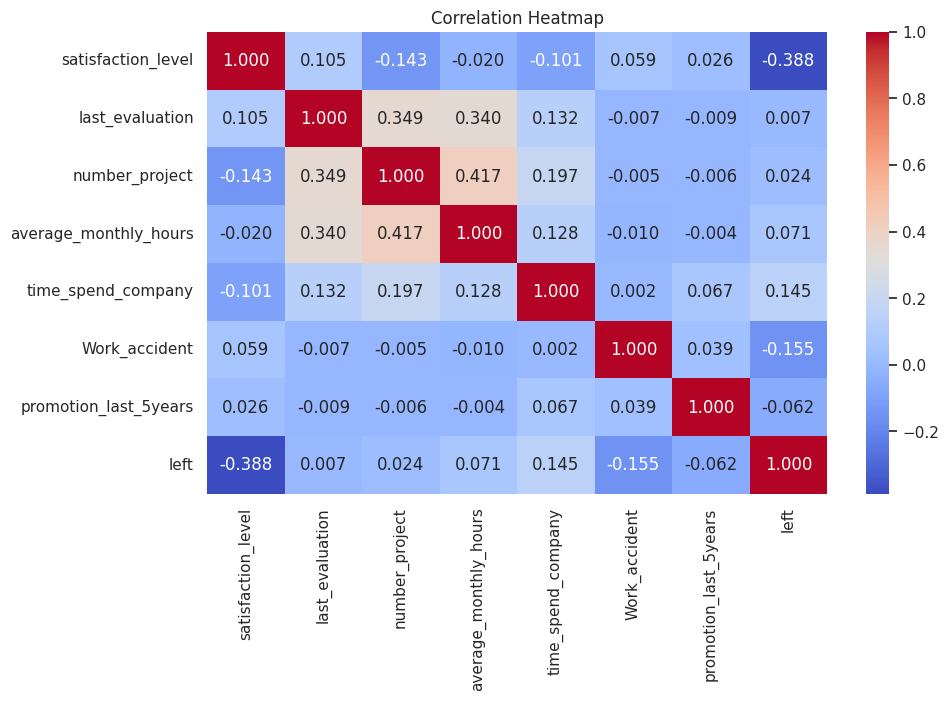

In [ ]:
#create correlation heatmap
sns.set_theme(style='whitegrid')

num_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_monthly_hours', 'time_spend_company', 'Work_accident',
            'promotion_last_5years', 'left']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


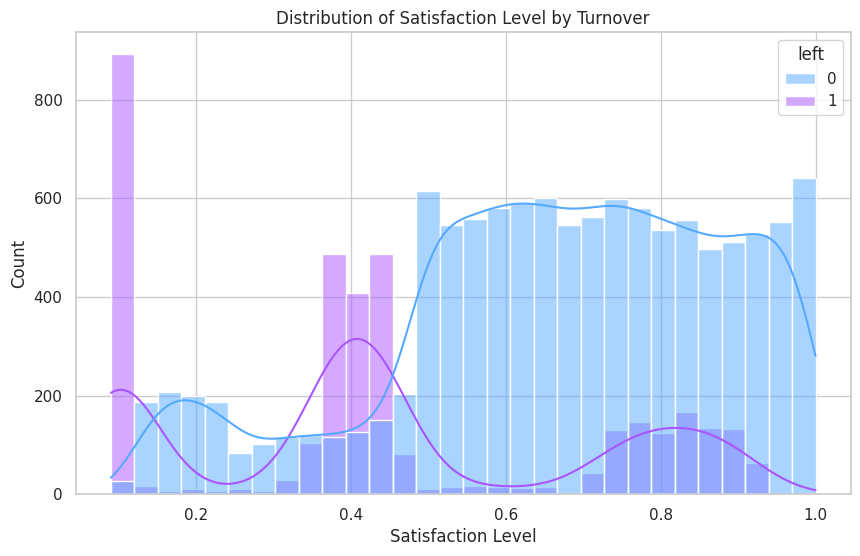

In [ ]:
# distribution plots for satisfaction level of employees

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='satisfaction_level', hue='left', kde=True, palette='cool')
plt.xlabel('Satisfaction Level')
plt.title('Distribution of Satisfaction Level by Turnover')
plt.show()

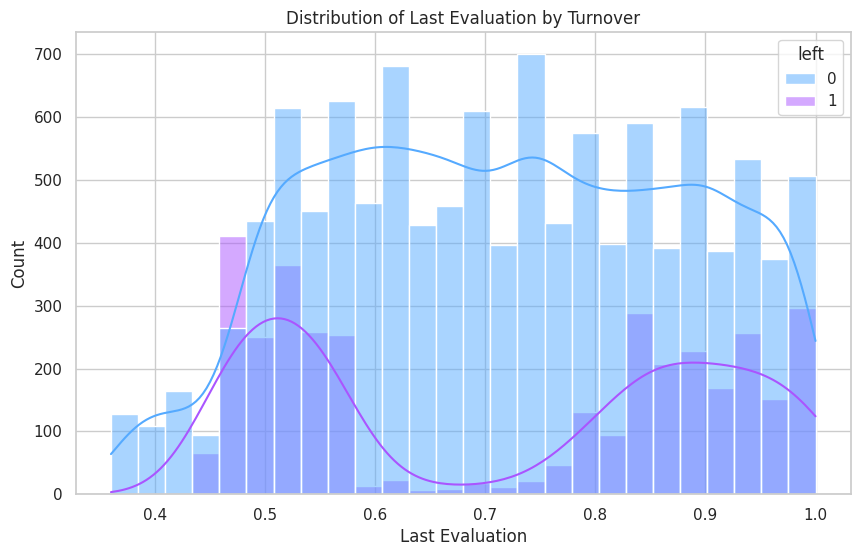

In [ ]:
# Employee Evaluation Chart

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='last_evaluation', hue='left', kde=True, palette='cool')
plt.xlabel('Last Evaluation')
plt.title('Distribution of Last Evaluation by Turnover')
plt.show()

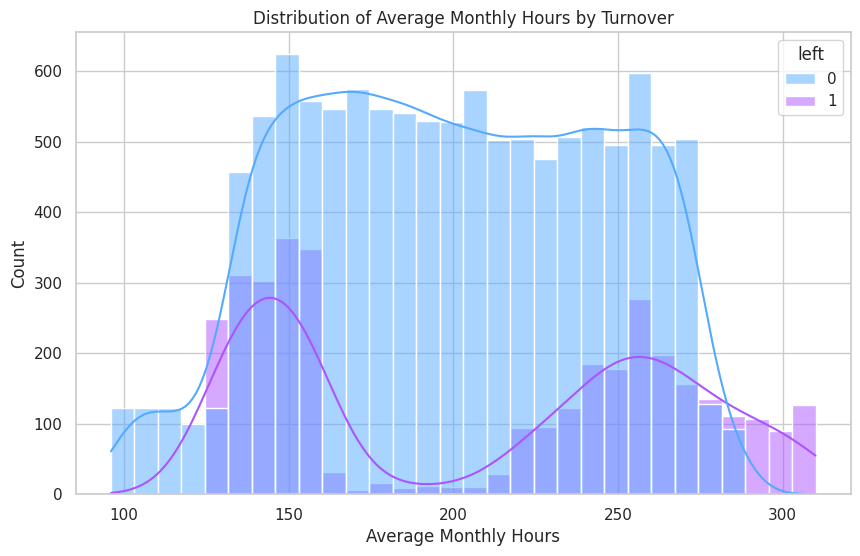

In [ ]:
# Employee Average Monthly Hours

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='average_monthly_hours', hue='left', kde=True, palette='cool')
plt.xlabel('Average Monthly Hours')
plt.title('Distribution of Average Monthly Hours by Turnover')
plt.show()

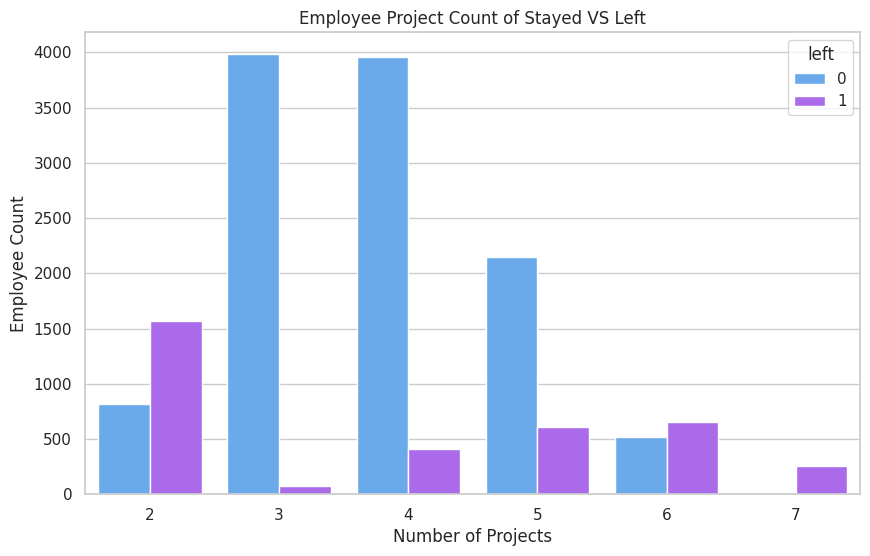

In [ ]:
# Employee Project Count of Stayed VS Left

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left', palette='cool')
plt.title('Employee Project Count of Stayed VS Left')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')
plt.show()


### analysis
- The employee project count analysis visualizes the range in which employees either choose to stay or leave. The opimal number to stay is from 3 to 5 projects as can be seen in the graph while at other amounts, turnover rate goes higher than those who stay.
- the trend suggests that employees either face underutilization or feel like they have an excessive workload, leading to higher turnover rates for those range of numbers.

---
##Perform clustering of employees

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



df_left = df[df['left']==1][['satisfaction_level', 'last_evaluation']]
df_left.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


In [ ]:
# create Kmeans model

mdl = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = mdl.fit_predict(df_left)

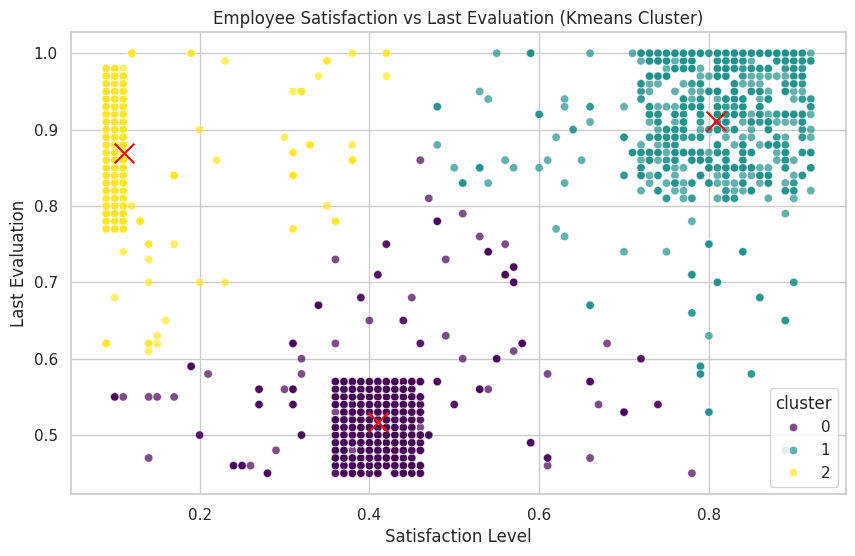

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_left, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='viridis', alpha=0.7)
plt.scatter(mdl.cluster_centers_[:, 0], mdl.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.title('Employee Satisfaction vs Last Evaluation (Kmeans Cluster)')
plt.show()

In [ ]:
centers = pd.DataFrame(mdl.cluster_centers_, columns=['satisfaction_level', 'last_evaluation'])
centers.round(3)

,satisfaction_level,last_evaluation
0,0.410,0.517
1,0.809,0.912
2,0.111,0.869


### Analysis

- Cluster 0: low evaluation and middling satisfaction levels show that employees were unhappy and disengaged with work. Could be employees as well who were burnt out as well and were going to leave
- Cluster 1: This cluster shows high satisfaction and evaluation scores. showing they were top performers, but still had reasons to leave. These could include amount of work, promotion amount, salary, among other things
- Cluster 2: Low satisfaction but high evaluation scores. Could showcase employees who were overworked and undervalued in the company. Motivated individuals who performed well shows a big risk for the company to fix.


---

##Handle the left Class Imbalance using the SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
num_cols

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_monthly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'left']

In [ ]:
cat_col = ['department', 'salary']
encode_df = pd.get_dummies(df, columns=cat_col, drop_first=True, dtype='int')
encode_df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0


In [ ]:
X = encode_df.drop(columns=['left'], axis=1)
y = encode_df['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

In [ ]:
print("before SMOTE:\n", y_train.value_counts(normalize=True).round(3))

before SMOTE:
 left
0    0.762
1    0.238
Name: proportion, dtype: float64


In [ ]:
smote = SMOTE(random_state=123)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

print("after SMOTE:\n", y_train_s.value_counts(normalize=True).round(3))

after SMOTE:
 left
0    0.5
1    0.5
Name: proportion, dtype: float64


---
## ML Classifiers with 5-fold Cross validations

In [ ]:
# first logistic regression
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report


log = LogisticRegression(max_iter=1000, random_state=123)
scores = cross_val_score(log, X_train_s, y_train_s, cv=5, scoring='accuracy')
print("Logistic Regression 5-fold CV Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))


Logistic Regression 5-fold CV Accuracy: 0.79 (+/- 0.06)


In [ ]:
log.fit(X_train_s, y_train_s)

LogisticRegression(max_iter=1000, random_state=123)

In [ ]:
y_pred = log.predict(X_test)
print("Logistic Classification Report:\n")
print(classification_report(y_test, y_pred))

Logistic Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      2286
           1       0.49      0.75      0.59       714

    accuracy                           0.75      3000
   macro avg       0.70      0.75      0.71      3000
weighted avg       0.81      0.75      0.77      3000



In [ ]:
# Random Forrest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=123)
rf_scores = cross_val_score(rf, X_train_s, y_train_s, cv=5, scoring='accuracy')
print("Random Forest 5-fold CV Accuracy: %0.2f (+/- %0.2f)" % (rf_scores.mean(), rf_scores.std() * 2))



Random Forest 5-fold CV Accuracy: 0.98 (+/- 0.00)


In [ ]:
rf.fit(X_train_s, y_train_s)


RandomForestClassifier(random_state=123)

In [ ]:
yrf_score = rf.predict(X_test)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, yrf_score))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [ ]:
# gradient boost
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=123)
gb_scores = cross_val_score(gb, X_train_s, y_train_s, cv=5, scoring='accuracy')
print("Gradient Boost 5-fold CV Accuracy: %0.2f (+/- %0.2f)" % (gb_scores.mean(), gb_scores.std() * 2))

Gradient Boost 5-fold CV Accuracy: 0.96 (+/- 0.00)


In [ ]:
gb.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=123)

In [ ]:
ygb_score = gb.predict(X_test)
print("Gradient Boost Classification Report:\n")
print(classification_report(y_test, ygb_score))

Gradient Boost Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.91      0.94      0.92       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



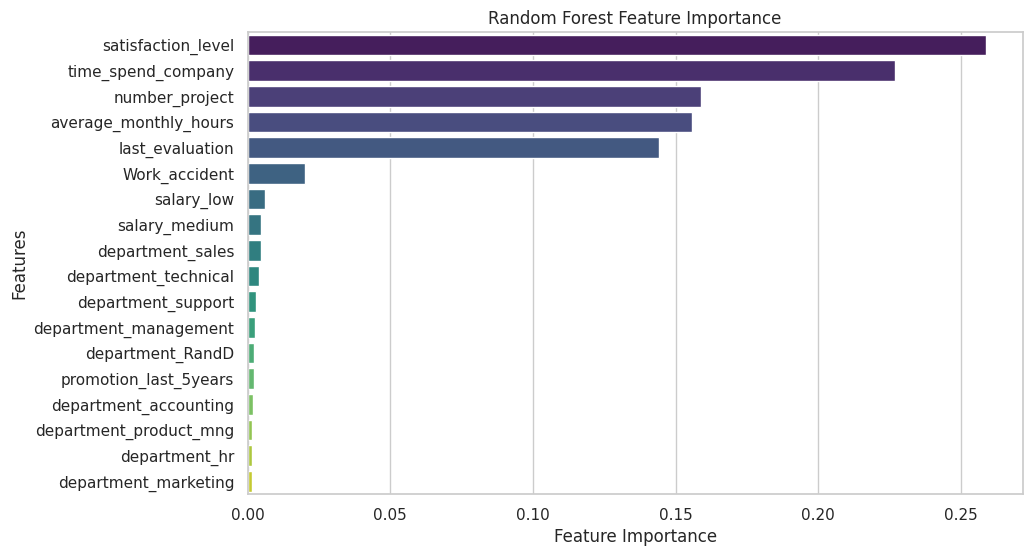

In [ ]:
rf_imp = pd.Series(rf.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_imp, y=rf_imp.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')
plt.show()

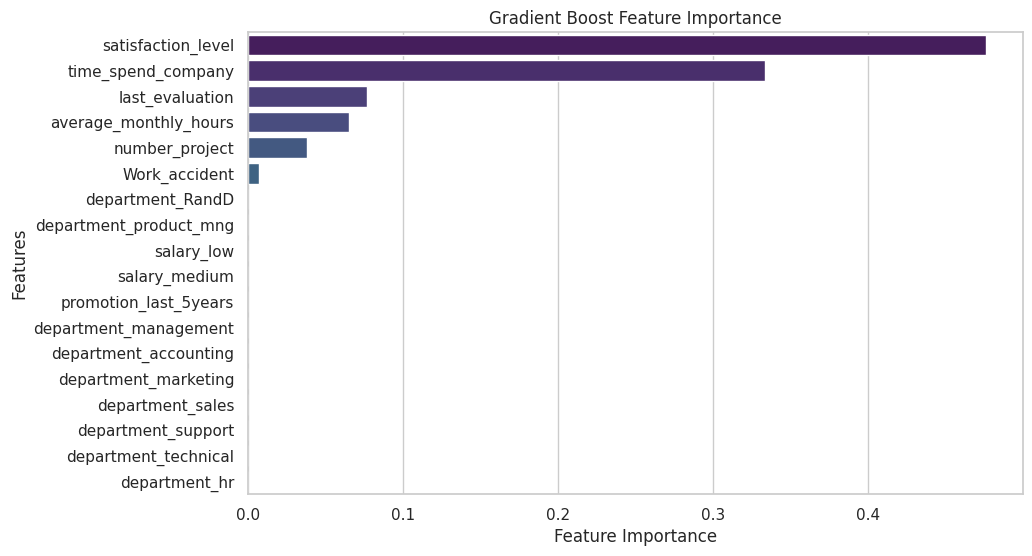

In [ ]:
gb_imp = pd.Series(gb.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=gb_imp, y=gb_imp.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Gradient Boost Feature Importance')
plt.show()

## Identify the best model

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
# Logistic regression
log_prb = log.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, log_prb)
auc_log = roc_auc_score(y_test, log_prb)

In [ ]:
# Random Forrest

rf_prb = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prb)
auc_rf = roc_auc_score(y_test, rf_prb)

In [ ]:
# Gradient Boost

gb_prb = gb.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prb)
auc_gb = roc_auc_score(y_test, gb_prb)


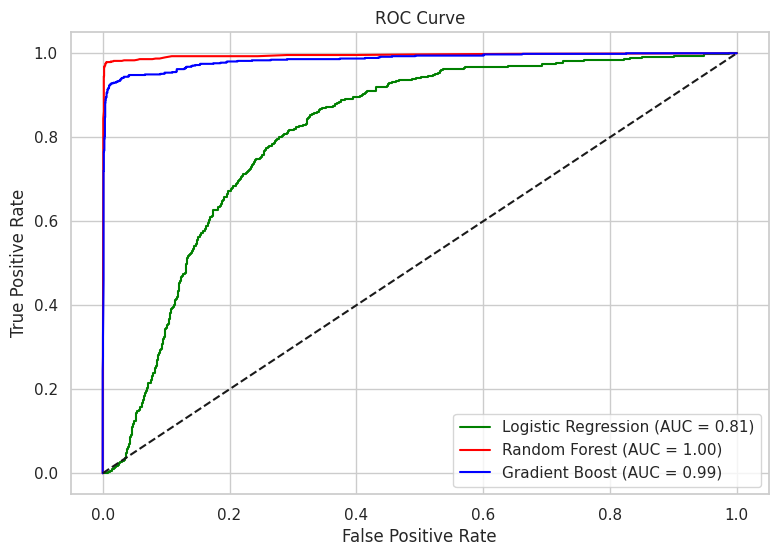

In [ ]:
# combine them

plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_log:.2f})', color='green')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='red')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boost (AUC = {auc_gb:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

log_pred = log.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nGradient Boost Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Logistic Regression Confusion Matrix:
[[1719  567]
 [ 178  536]]

Random Forest Confusion Matrix:
[[2265   21]
 [  15  699]]

Gradient Boost Confusion Matrix:
[[2222   64]
 [  45  669]]


## Which is more important?
- Recall is more important to focus on for these models
- is allows us to focus on the amount we correctly predicted who left, which is what is important when trying to understand and predict why people are leaving.
- high recall (.99) allows us to catch most of those at-risk of leaving.
- This data shows Random Forrest is the best model presented here

In [78]:
# create employee Zones

zones = pd.cut(rf_prb, bins=[-1, 0.2, 0.6, 0.9, 1.01], labels=['Safe Green', 'Low Yellow', 'Medium Orange', 'High Red'])
zones.value_counts()


,count
Safe Green,2153
Low Yellow,142
Medium Orange,54
High Red,651


In [79]:
result = pd.DataFrame({
    "y_true": y_test.values,
    "Leave_prob": rf_prb,
    "zone": zones
}, index=X_test.index)
result

,y_true,Leave_prob,zone
10627,0,0.00,Safe Green
2703,0,0.56,Low Yellow
6059,0,0.09,Safe Green
3258,0,0.00,Safe Green
4565,0,0.01,Safe Green
...,...,...,...
4961,0,0.00,Safe Green
4557,0,0.01,Safe Green
6610,0,0.04,Safe Green
10327,0,0.02,Safe Green


## Analysis
- Based on the data of using the Random Forrest to predict what zone each individual would fall into to predict if they would leave or not, it can be seen that around 70% are not at risk to leave
- While those in the Yellow and Medium Zones are in the low end of probability to leave with a lot less in total amounts
- But around 20% of the predictions presented show there is a high risk they will leave if their situation is not improved
  - Rentention Strategies could include giving higher wages to employees, giving them more meaningful work and surround them with the best resources to get them help if they are needing it with work or even personal issues.
  - Allowing employees to focus on their work while still allowing them to get a work-life balance may allow them to not have such a high risk of leaving the company